## TP3 - Visión por Computadora 1

### Objetivo:
Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en  
`Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template

1. Obtener una detección del logo en cada imagen sin falsos positivos

In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Configuración
TEMPLATE_PATH = "./template/pattern.png"
IMAGES_DIR = "./images"

def load_and_preprocess_template(template_path):
    """Carga y binariza el template para resaltar letras."""
    template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)

    # Ajustar contraste    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    template = clahe.apply(template)
    
    # Suavizado de ruido con kernel pequeño para mantener los bordes
    template = cv2.GaussianBlur(template, (3,3), 0)
    
    # Aplicar umbral adaptativo
    template = cv2.adaptiveThreshold(
        template,
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, # resaltar los bordes, bueno para detección ORB
        cv2.THRESH_BINARY_INV,          # bordes blancos sobre fondo negro.
        11,
        2
    )
    
    # Eliminar prqueños ruidos y suaviza los bordes
    kernel = np.ones((3,3), np.uint8)
    template = cv2.morphologyEx(template, cv2.MORPH_OPEN, kernel)
    return template

def init_orb_detector():
    """Configuración ORB optimizada para texto."""
    return cv2.ORB_create(
        nfeatures=2000, 
        scaleFactor=1.1, 
        nlevels=12, 
        edgeThreshold=31,
        patchSize=31,
        fastThreshold=20
    )

def match_features(des1, des2, ratio=0.8):
    """Matcher con Ratio Test estándar."""
    # Usar BFMatcher con distancia Hamming
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    
    # Encontrar los 2 mejores matches
    matches = bf.knnMatch(des1, des2, k=2)
    
    # Aplicar ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good_matches.append(m)
            
    return good_matches

def validate_geometry(pts):
    """Filtra detecciones con formas extrañas."""
    pts_int = np.int32(pts)
    
    # Área mínima
    if cv2.contourArea(pts_int) < 600: return False, f"Muy pequeño {cv2.contourArea(pts_int)}"

    # Aspect Ratio (Ancho vs Alto)
    rect = cv2.minAreaRect(pts_int)
    _, (w, h), _ = rect
    dim1, dim2 = max(w, h), min(w, h)
    if dim2 == 0:
        return False, "Dimensión cero"
    ratio = dim1 / dim2
    
    # El logo es alargado, pero permitimos cierta deformación
    if ratio < 0.9 or ratio > 12.0: 
        return False, f"Ratio extraño ({ratio:.1f})"

    # Convexidad relajada
    if not cv2.isContourConvex(pts_int):
        hull = cv2.convexHull(pts_int)
        if cv2.contourArea(pts_int) / cv2.contourArea(hull) < 0.8:
             return False, "Forma muy deforme"
        
    return True, "OK"

def plot_keypoints(image, keypoints, title="Keypoints del template:", figsize=(10, 6), color=(0, 255, 0)):
    # (x, y) de los keypoints
    keypoints = np.float32([kp.pt for kp in keypoints])
    # Convertir las coordenadas a objetos KeyPoint de OpenCV
    kp_objects = [cv2.KeyPoint(x, y, 5) for x, y in keypoints]
    
    # Dibujar los keypoints en la imagen
    img_with_kp = cv2.drawKeypoints(
        image, 
        kp_objects, 
        None, 
        color=color,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # Mostrar la imagen con los keypoints
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
    plt.title(f'{title} {len(keypoints)}')
    plt.axis('off')
    plt.show()

def visualize(template, kp_temp, img_resized, kp_resized, matches, mask, img_original, dst_box, titulo):
    """
    Dibuja los matches y la detección final sin errores de escala.
    """
    # Matches: Se dibujan sobre la imagen REDIMENSIONADA (donde coinciden las coordenadas)
    draw_params = dict(matchColor=(0, 255, 0), singlePointColor=None, matchesMask=mask.ravel().tolist(), flags=2)
    img_matches = cv2.drawMatches(template, kp_temp, img_resized, kp_resized, matches, None, **draw_params)
    
    # Caja - detect: Se dibuja sobre la imagen ORIGINAL
    img_final = img_original.copy()
    cv2.polylines(img_final, [np.int32(dst_box)], True, (0, 255, 0), 5, cv2.LINE_AA)

    # Plot
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_matches)
    plt.title("Coincidencias (ORB)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.title(f"Resultado Final: {titulo}")
    plt.axis('off')
    plt.show()

Iniciando detección...


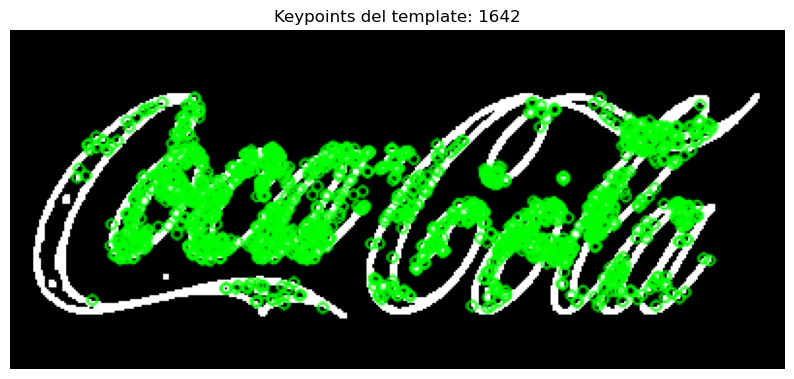


Procesando: COCA-COLA-LOGO.jpg
DETECTADO en modo: Normal | Inliers: 32


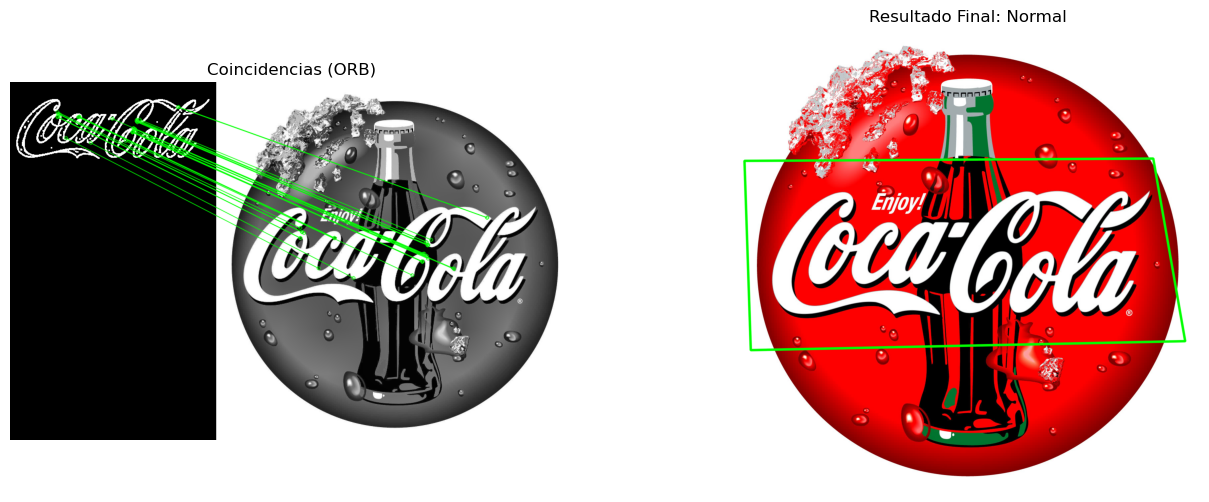


Procesando: coca_multi.png

Procesando: coca_logo_1.png
DETECTADO en modo: Normal | Inliers: 55


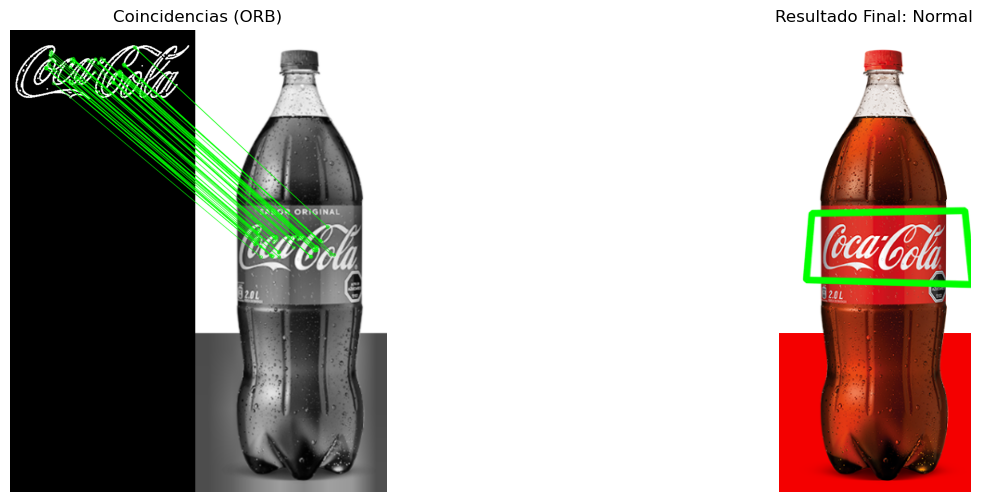


Procesando: coca_retro_1.png
DETECTADO en modo: Invertida | Inliers: 20


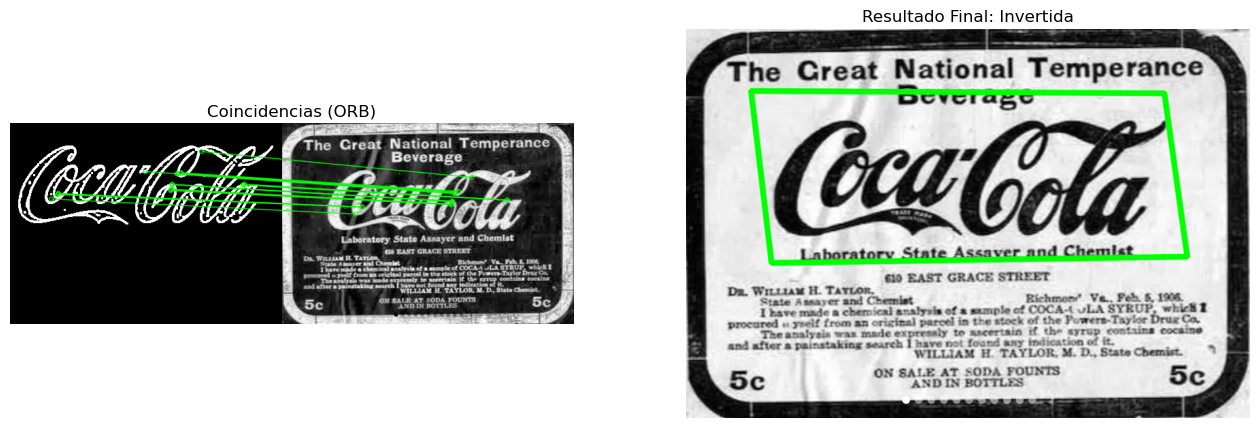


Procesando: logo_1.png
DETECTADO en modo: Normal | Inliers: 27


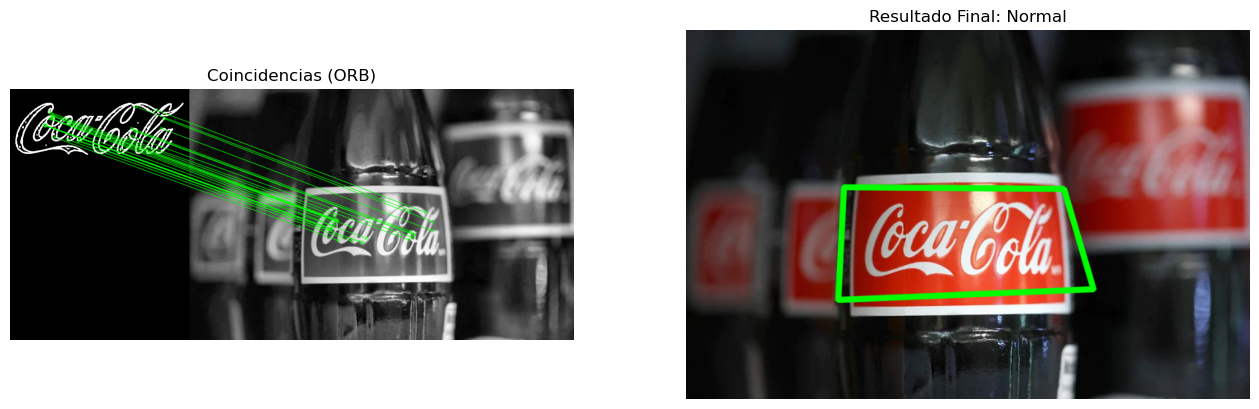


Procesando: coca_logo_2.png
DETECTADO en modo: Normal | Inliers: 19


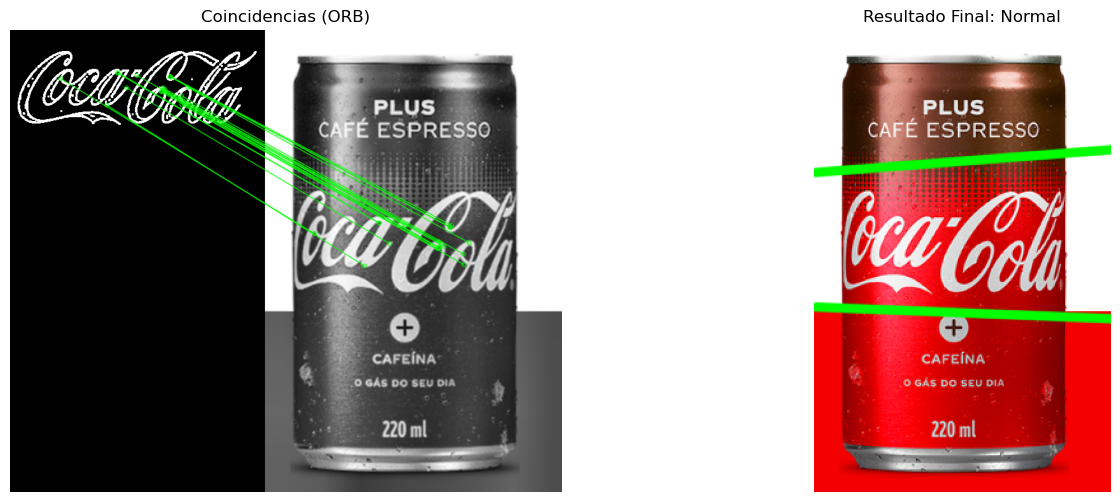


Procesando: coca_retro_2.png
DETECTADO en modo: Normal | Inliers: 22


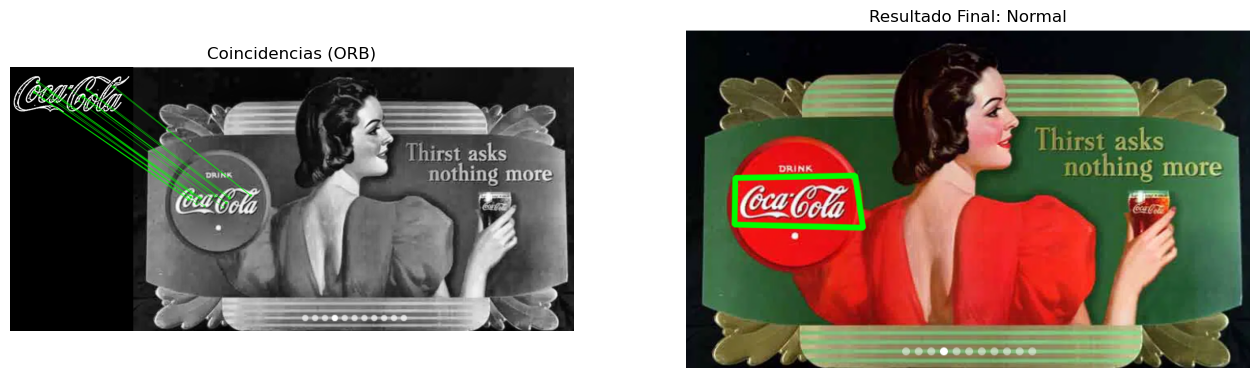

In [31]:
print("Iniciando detección...")

# Cargar Template
template = load_and_preprocess_template(TEMPLATE_PATH)
h_temp, w_temp = template.shape[:2]

# Iniciar ORB en template
orb = init_orb_detector()
kp1, des1 = orb.detectAndCompute(template, None)

# Se muestran los keypoints    
plot_keypoints(template, kp1)

# Buscar imágenes
patrones = ['*.jpg', '*.png']
img_paths = []
for p in patrones:
    img_paths.extend(glob(os.path.join(IMAGES_DIR, p)))

for img_path in img_paths:
    filename = os.path.basename(img_path)
    print(f"\nProcesando: {filename}")
    
    # Se carga la imagen
    original_img = cv2.imread(img_path)
    
    # Preproceso imagen
    gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray_clahe = clahe.apply(gray)
    
    # Estrategia Doble: Buscar en Normal e Invertida
    modos = [(gray_clahe, "Normal"), (cv2.bitwise_not(gray_clahe), "Invertida")]
    exito = False

    for img_proc, modo in modos:
        if exito: # Si el modo Normal funciona no probar la Invertida. 
            break
        
        # Escalas a probar
        scales = [0.25, 0.35, 0.5, 0.6, 0.75, 0.9, 1.0, 1.1, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4, 4.5, 5]
        
        best_len = 0
        best_scale = 1.0
        best_pack = None # (matches, kp2, des2, resized_img)
        
        for s in scales:
            h, w = img_proc.shape
            new_w, new_h = int(w * s), int(h * s) # escala
            
            # Evitar errores si es muy chica
            if new_w < w_temp or new_h < h_temp:
                continue
            
            resized = cv2.resize(img_proc, (new_w, new_h))
            kp2, des2 = orb.detectAndCompute(resized, None)
            
            matches = match_features(des1, des2, ratio=0.8)
            
            if len(matches) > best_len:
                best_len = len(matches)
                best_scale = s
                best_pack = (matches, kp2, des2, resized)

        # Despues de probar las diferentes escalas, si encontramos un número de matches prometedor
        if best_len >= 5:
            matches, kp2, des2, img_resized = best_pack
            
            src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
            
            # RANSAC Tolerante (15.0) para botellas curvas
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 15.0)
            
            if M is not None: # M valida
                # puntos que cumplen con el modelo de homografía según RANSAC
                inliers = sum(mask.ravel().tolist())
                
                if inliers >= 5:
                    
                    # Proyectar caja en la imagen REDIMENSIONADA
                    pts_box = np.float32([[0, 0], [0, h_temp-1], [w_temp-1, h_temp-1], [w_temp-1, 0]]).reshape(-1, 1, 2)
                    dst_resized = cv2.perspectiveTransform(pts_box, M)
                    
                    # Validar geometría
                    valido, motivo = validate_geometry(dst_resized)
                    
                    if valido:
                        print(f"DETECTADO en modo: {modo} | Inliers: {inliers}")
                        
                        # Escalar la caja para la imagen ORIGINAL
                        dst_original = dst_resized / best_scale
                        
                        # Visualizar
                        visualize(template, kp1, img_resized, kp2, matches, mask, original_img, dst_original, modo)
                        exito = True
                    else:
                        pass
                        #print(f"Descartado en modo: {modo} por motivo: {motivo}")

    
    # if not exito:
    #     print("No se encontró el logo.")

2. Plantear y validar un algoritmo para múltiples detecciones en la imagen
coca_multi.png con el mismo témplate del ítem 1

In [ ]:
#WIP